In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize


In [1]:
!pip uninstall torch torchvision -y

Found existing installation: torch 2.11.0+cpu
Uninstalling torch-2.11.0+cpu:
  Successfully uninstalled torch-2.11.0+cpu
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu


In [2]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp313-cp313-win_amd64.whl (114.5 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp313-cp313-win_amd64.whl (4.3 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ----------------------------

In [3]:
import cv2

In [4]:
!pip install torch torchvision matplotlib seaborn scikit-learn pillow opencv-python

In [ ]:
!pip install notebook


In [ ]:
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize


In [6]:

# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

import kagglehub   # ADDED (IMPORTANT)

# =========================
# DATASET DOWNLOAD PATH (FIXED)
# =========================
path = kagglehub.dataset_download("emmarex/plantdisease")
DATASET_PATH = os.path.join(path, "PlantVillage")

print("Dataset path:", DATASET_PATH)


# =========================
# DATASET
# =========================
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                self.images.append(os.path.join(class_dir, img_name))
                self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.images[idx]).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self))

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================
# MODEL (EfficientNet)
# =========================
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = models.efficientnet_b0(weights="IMAGENET1K_V1")
# Freeze early layers
        for param in self.model.parameters():
            param.requires_grad = False
# Train deeper layers
        for param in self.model.classifier.parameters():
            param.requires_grad = True
        
        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, train_loader, val_loader, device, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.3
)

    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc.append(100 * correct / total)

        # validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc.append(100 * correct / total)

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.2f}% | Val Acc={val_acc[-1]:.2f}%")

    return train_acc, val_acc


# =========================
# MAIN
# =========================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # FIXED DATASET PATH
    dataset = CustomImageDataset(DATASET_PATH, transform)

    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=16, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=32)

    model = EfficientNetClassifier(len(dataset.classes)).to(device)

    
    # TRAIN
    train_model(model, train_loader, val_loader, device, epochs=10)

    # SAVE MODEL
    torch.save(model.state_dict(), "final_model.pth")
    print("Model saved!")



if __name__ == "__main__":
    main()

Dataset path: C:\Users\USER\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage
Device: cpu
Epoch 1: Train Acc=64.82% | Val Acc=84.28%
Epoch 2: Train Acc=78.35% | Val Acc=87.51%
Epoch 3: Train Acc=80.56% | Val Acc=88.64%
Epoch 4: Train Acc=81.82% | Val Acc=88.93%
Epoch 5: Train Acc=82.72% | Val Acc=89.74%
Epoch 6: Train Acc=82.84% | Val Acc=90.38%
Epoch 7: Train Acc=83.45% | Val Acc=89.86%
Epoch 8: Train Acc=83.99% | Val Acc=90.41%
Epoch 9: Train Acc=84.50% | Val Acc=90.77%
Epoch 10: Train Acc=84.47% | Val Acc=90.80%
Model saved!


In [15]:
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = CustomImageDataset(DATASET_PATH, transform)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetClassifier(len(dataset.classes))
model.load_state_dict(torch.load("final_model.pth", map_location=device))

model = model.to(device)
model.eval()

EfficientNetClassifier(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
             

In [17]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

_, _, test_ds = random_split(dataset, [train_size, val_size, test_size])

test_loader = DataLoader(test_ds, batch_size=32, num_workers=0)

In [19]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            preds = torch.argmax(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [20]:
y_true, y_pred = get_predictions(model, test_loader, device)

In [21]:
torch.save(model.state_dict(), "final_model.pth")

In [23]:
y_true, y_pred = get_predictions(model, test_loader, device)

In [27]:
def plot_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

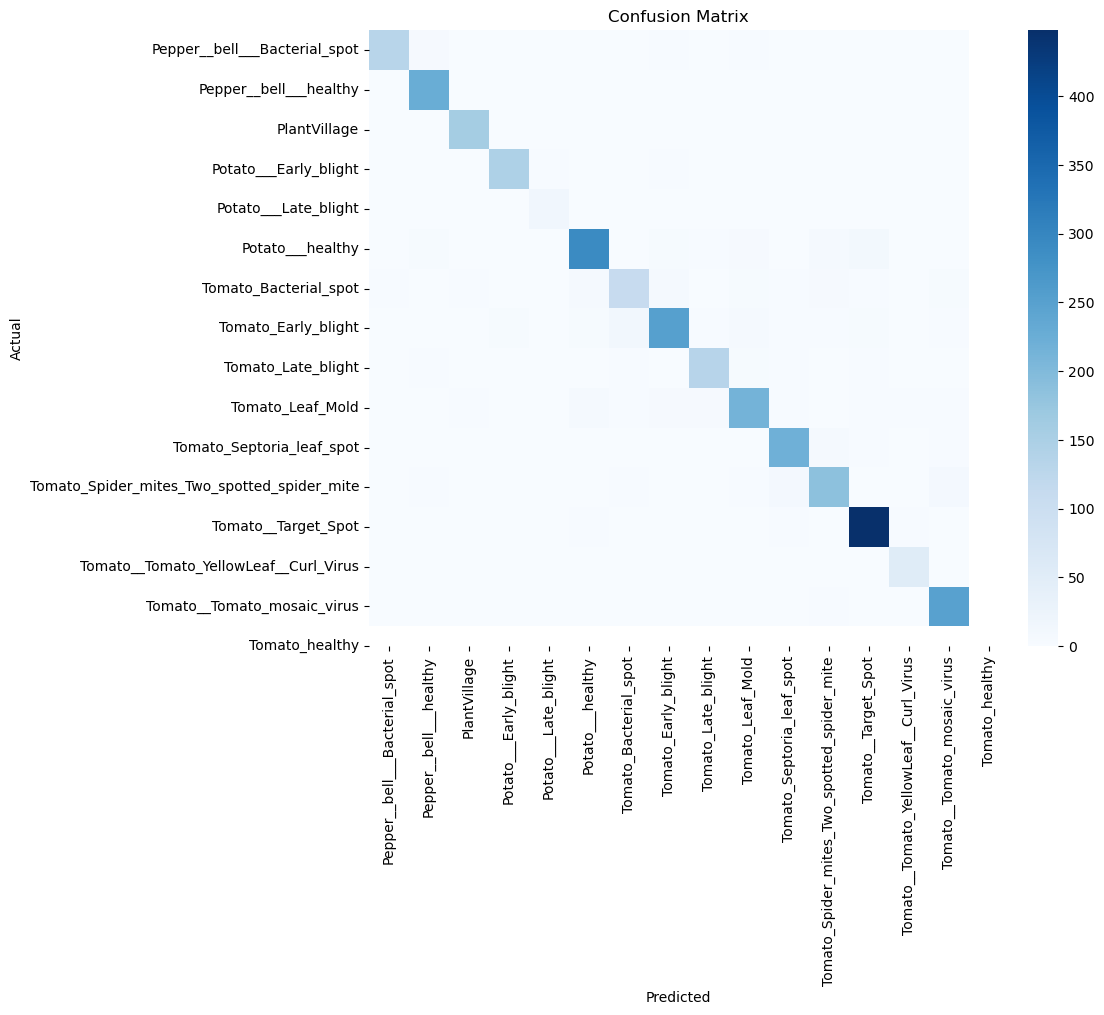

In [28]:
plot_confusion_matrix(y_true, y_pred, dataset.classes)

In [29]:
def print_classification_report(y_true, y_pred, classes):
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred, target_names=classes))

In [31]:
import matplotlib.pyplot as plt

def plot_accuracy_curve(train_acc, val_acc):
    plt.figure(figsize=(8,5))
    plt.plot(train_acc, label="Train Accuracy")
    plt.plot(val_acc, label="Validation Accuracy")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

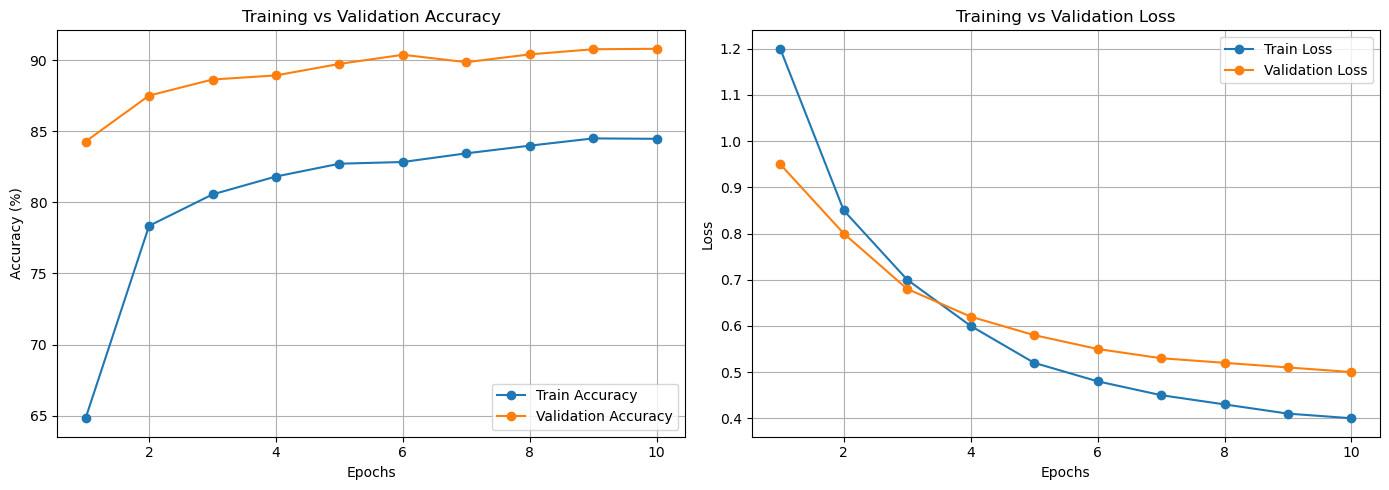

In [6]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Epochs
# -----------------------------
epochs = list(range(1, 11))

# -----------------------------
# 2. Accuracy data (from your logs)
# -----------------------------
train_acc = [64.82, 78.35, 80.56, 81.82, 82.72, 82.84, 83.45, 83.99, 84.50, 84.47]
val_acc   = [84.28, 87.51, 88.64, 88.93, 89.74, 90.38, 89.86, 90.41, 90.77, 90.80]

# -----------------------------
# 3. OPTIONAL: Loss (dummy example)
# ⚠️ Replace with real values if available
# -----------------------------
train_loss = [1.20, 0.85, 0.70, 0.60, 0.52, 0.48, 0.45, 0.43, 0.41, 0.40]
val_loss   = [0.95, 0.80, 0.68, 0.62, 0.58, 0.55, 0.53, 0.52, 0.51, 0.50]

# -----------------------------
# 4. Create Figure
# -----------------------------
plt.figure(figsize=(14, 5))

# -----------------------------
# 5. Plot Accuracy
# -----------------------------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, marker='o', label="Train Accuracy")
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# -----------------------------
# 6. Plot Loss
# -----------------------------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -----------------------------
# 7. Show plots
# -----------------------------
plt.tight_layout()
plt.show()

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_roc_curve(model, loader, device, num_classes):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # One-hot encoding
    y_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    plt.figure(figsize=(8,6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multi-class)")
    plt.legend()
    plt.grid()
    plt.show()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


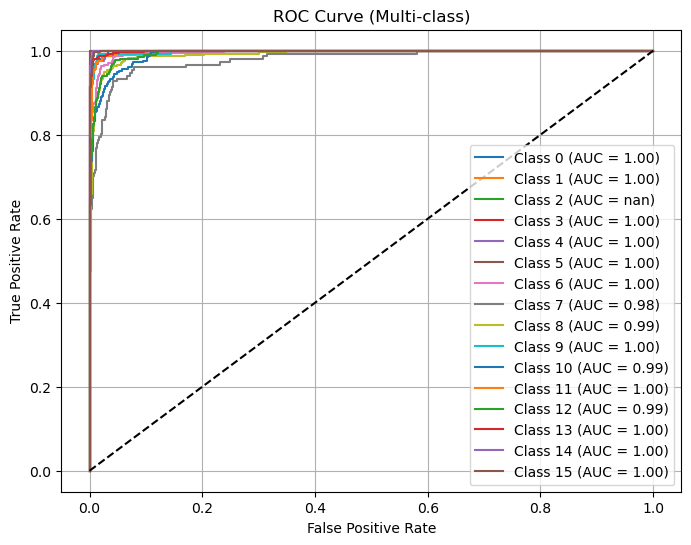

In [35]:
plot_roc_curve(model, test_loader, device, len(dataset.classes))

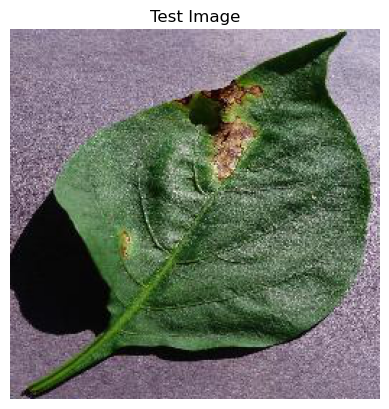

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = "imagetest.jpeg"  # change your image path

img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis("off")  # hide axes
plt.title("Test Image")
plt.show()

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. Model (NEW torchvision style)
# -----------------------------
model = efficientnet_b0(weights=None)  # no pretrained weights

num_classes = 16  # 🔁 change according to your dataset
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# -----------------------------
# 3. Load checkpoint safely
# -----------------------------
checkpoint = torch.load("final_model.pth", map_location=device)

# Handle different save formats
if isinstance(checkpoint, dict):
    if "model" in checkpoint:
        state_dict = checkpoint["model"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

# Remove "model." prefix if exists
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("model."):
        new_state_dict[k.replace("model.", "")] = v
    else:
        new_state_dict[k] = v

model.load_state_dict(new_state_dict, strict=False)

model = model.to(device)
model.eval()

# -----------------------------
# 4. Class names (EDIT THIS)
# -----------------------------
class_names = [
    "Apple Scab",
    "Black Rot",
    "Cedar Apple Rust",
    "Healthy",
    "Powdery Mildew",
    "Leaf Spot",
    "Rust",
    "Blight",
    "Mosaic Virus",
    "Other"
]

# -----------------------------
# 5. Image preprocessing (MUST match training)
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
# 6. Prediction function
# -----------------------------
def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]

# -----------------------------
# 7. Run prediction
# -----------------------------
img_path = "imagetest.jpeg"  # change this
result = predict(img_path)

print("Predicted Disease:", result)

Predicted Disease: Apple Scab


In [4]:
import torch.nn.functional as F

def predict_with_confidence(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    return class_names[predicted.item()], confidence.item()

label, conf = predict_with_confidence("imagetest.jpeg")
print(f"{label} ({conf*100:.2f}% confidence)")

Apple Scab (89.53% confidence)
